##Problem Statement
The Online E-commerce company want to Predict whether a customer will return to shop in the next 3 months based on their past behavior and engagement to focus on the marketing of that customer

##Import Libraries

In [137]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


##Load data

In [138]:
df = pd.read_csv("/content/customer_return_prediction.csv")

##Basic analysis

In [139]:
df.head()

,CustomerID,Age,Gender,TotalPurchasesLast6Months,AvgOrderValue,BrowsingTime,DiscountUsage,CustomerSupportInteractions,DaysSinceLastPurchase,EmailClicksLastMonth,AppSessionsLastWeek,WillReturn
0,1,49,Female,1,4319.21,536.0,7.0,7,73,23,28,1
1,2,29,Female,44,2235.14,545.0,5.0,1,25,5,21,1
2,3,35,Male,40,789.00,232.0,8.0,9,28,45,2,1
3,4,24,Male,32,6868.02,183.0,29.0,8,44,6,10,1
4,5,41,Male,23,6713.88,484.0,10.0,0,67,27,12,1


In [140]:
df.shape

(5000, 12)

In [141]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   CustomerID                   5000 non-null   int64  
 1   Age                          5000 non-null   int64  
 2   Gender                       5000 non-null   object 
 3   TotalPurchasesLast6Months    5000 non-null   int64  
 4   AvgOrderValue                4850 non-null   float64
 5   BrowsingTime                 4850 non-null   float64
 6   DiscountUsage                4850 non-null   float64
 7   CustomerSupportInteractions  5000 non-null   int64  
 8   DaysSinceLastPurchase        5000 non-null   int64  
 9   EmailClicksLastMonth         5000 non-null   int64  
 10  AppSessionsLastWeek          5000 non-null   int64  
 11  WillReturn                   5000 non-null   int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 468.9+ KB


In [142]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
CustomerID,5000.0,2500.500000,1443.520003,1.00,1250.7500,2500.500,3750.2500,5000.00
Age,5000.0,40.944200,13.609149,18.00,29.0000,41.000,53.0000,64.00
TotalPurchasesLast6Months,5000.0,30.223800,20.085756,0.00,14.0000,29.000,45.0000,177.00
AvgOrderValue,4850.0,3547.055381,2128.437039,55.44,1703.1925,3522.015,5238.2725,13998.22
BrowsingTime,4850.0,302.285979,171.459801,5.00,151.0000,300.000,453.0000,599.00
DiscountUsage,4850.0,14.435258,8.676612,0.00,7.0000,14.000,22.0000,29.00
CustomerSupportInteractions,5000.0,4.564600,2.871912,0.00,2.0000,5.000,7.0000,9.00
DaysSinceLastPurchase,5000.0,44.364000,26.009560,0.00,22.0000,44.000,67.0000,89.00
EmailClicksLastMonth,5000.0,24.566400,14.479721,0.00,12.0000,25.000,37.0000,49.00
AppSessionsLastWeek,5000.0,14.338200,8.614236,0.00,7.0000,14.000,22.0000,29.00


##Remove unwanted columns like unique columns

In [143]:
df.drop(columns=["CustomerID"], inplace=True, axis=1)

In [144]:
df.shape

(5000, 11)

##Handle the Unknown Values

In [145]:
df.isin(['?','/','Unknown']).sum()

,0
Age,0
Gender,0
TotalPurchasesLast6Months,0
AvgOrderValue,0
BrowsingTime,0
DiscountUsage,0
CustomerSupportInteractions,0
DaysSinceLastPurchase,0
EmailClicksLastMonth,0
AppSessionsLastWeek,0


#Handle the null values

In [146]:
df.isnull().sum()

,0
Age,0
Gender,0
TotalPurchasesLast6Months,0
AvgOrderValue,150
BrowsingTime,150
DiscountUsage,150
CustomerSupportInteractions,0
DaysSinceLastPurchase,0
EmailClicksLastMonth,0
AppSessionsLastWeek,0


- There is found null values in dataset in the AvgOrderValue,BrowsingTime,DiscountUsage columns.
- we have to manage them, data present in columns are float type therefore we use median() to manage the null values

In [147]:
df.isnull().sum()
# Fill numerical columns with median
df['AvgOrderValue'].fillna(df['AvgOrderValue'].median(), inplace=True)
df['BrowsingTime'].fillna(df['BrowsingTime'].median(), inplace=True)
df['DiscountUsage'].fillna(df['DiscountUsage'].median(), inplace=True)

In [148]:
df.isnull().sum()

,0
Age,0
Gender,0
TotalPurchasesLast6Months,0
AvgOrderValue,0
BrowsingTime,0
DiscountUsage,0
CustomerSupportInteractions,0
DaysSinceLastPurchase,0
EmailClicksLastMonth,0
AppSessionsLastWeek,0


After the handling there is no any null values in dataset

##Handle the duplicate values

In [149]:
df.duplicated().sum()

np.int64(0)

There is no any duplicate values in the dataset

In [150]:
df.shape

(5000, 11)

##Divide the columns into the categorical and numerical columns

In [151]:
## split the data into the categorical and numerical data

categorical_columns = df.select_dtypes(include = 'object').columns
numerical_columns = df.select_dtypes(exclude = 'object').columns

In [152]:
categorical_columns

Index(['Gender'], dtype='object')

In [153]:
numerical_columns

Index(['Age', 'TotalPurchasesLast6Months', 'AvgOrderValue', 'BrowsingTime',
       'DiscountUsage', 'CustomerSupportInteractions', 'DaysSinceLastPurchase',
       'EmailClicksLastMonth', 'AppSessionsLastWeek', 'WillReturn'],
      dtype='object')

##Convert the categorical_columns into the numerical data

In [154]:
from sklearn.preprocessing import LabelEncoder





In [155]:
le = LabelEncoder()

In [156]:
df['Gender'] = le.fit_transform(df['Gender'])

In [157]:
df

,Age,Gender,TotalPurchasesLast6Months,AvgOrderValue,BrowsingTime,DiscountUsage,CustomerSupportInteractions,DaysSinceLastPurchase,EmailClicksLastMonth,AppSessionsLastWeek,WillReturn
0,49,0,1,4319.21,536.0,7.0,7,73,23,28,1
1,29,0,44,2235.14,545.0,5.0,1,25,5,21,1
2,35,1,40,789.00,232.0,8.0,9,28,45,2,1
3,24,1,32,6868.02,183.0,29.0,8,44,6,10,1
4,41,1,23,6713.88,484.0,10.0,0,67,27,12,1
...,...,...,...,...,...,...,...,...,...,...,...
4995,41,1,45,71.09,136.0,18.0,5,62,40,18,1
4996,18,0,5,2644.99,229.0,21.0,2,12,26,18,1
4997,28,0,1,3427.97,451.0,4.0,4,61,31,19,0
4998,56,0,10,1840.68,91.0,16.0,4,61,26,10,0


We convert the gender column into the numerical columns Male=1 and Female=0

##Find and remove the Outliers

In [158]:
Q1=df.quantile(0.25)
Q3=df.quantile(0.75)

IQR=Q3-Q1


df=df[~((df < (Q1-1.5*IQR)) |(df> (Q3+1.5*IQR))).any(axis=1)]

In [159]:
df.shape

(4171, 11)

##Univariate Analysis

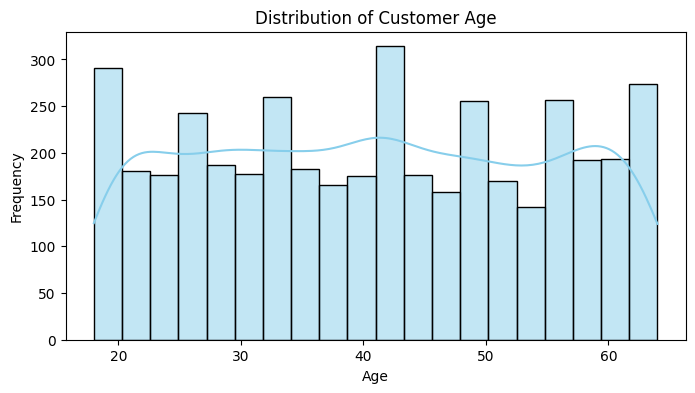

In [160]:
plt.figure(figsize=(8,4))
sns.histplot(df['Age'], kde=True, bins=20, color='skyblue')
plt.title('Distribution of Customer Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

Most customers are between 20-35 years old
A smaller portion of older customers (50-65) still shop online but less frequently.
Age may influence return probability, younger customers may be more engaged with the platform

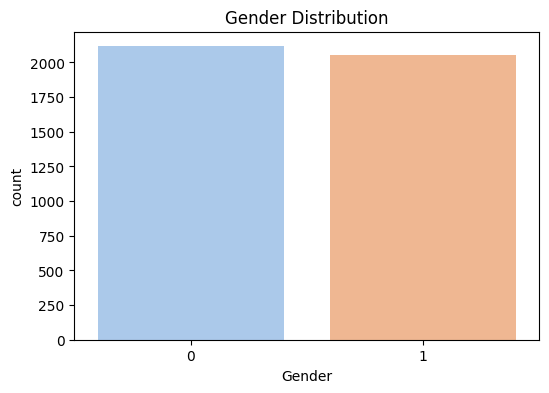

In [161]:
plt.figure(figsize=(6,4))
sns.countplot(x='Gender', data=df, palette='pastel')
plt.title('Gender Distribution')
plt.show()


 The dataset has roughly balanced Male and Female customers both are comparativly the same count of frequency

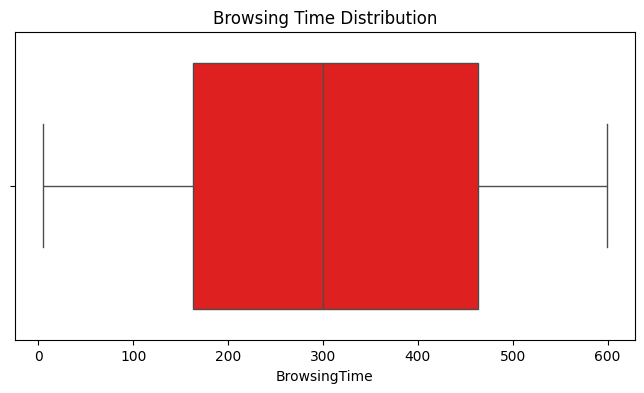

In [162]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df['BrowsingTime'], color='red')
plt.title('Browsing Time Distribution')
plt.show()

Most customers spend under 300 minutes browsing per week Other are extremely high browsing times may indicate window shoppers

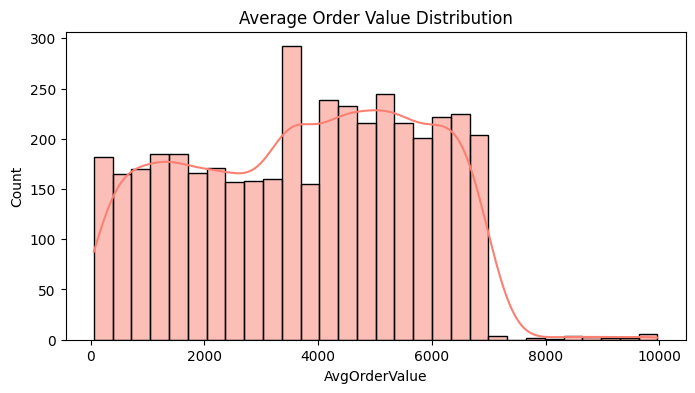

In [163]:
plt.figure(figsize=(8,4))
sns.histplot(df['AvgOrderValue'], bins=30, kde=True, color='salmon')
plt.title('Average Order Value Distribution')
plt.show()

Distribution is right-skewed Few customers have extremely high AvgOrderValue from the 4000 to the 7000 AvgOrderValue have the highest count of the frequency

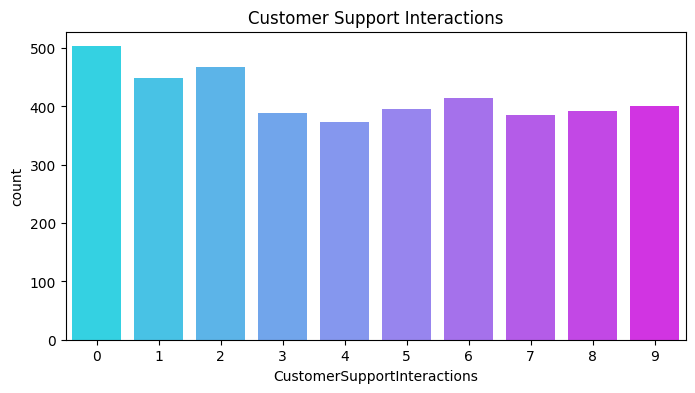

In [164]:
plt.figure(figsize=(8,4))
sns.countplot(x='CustomerSupportInteractions', data=df, palette='cool')
plt.title('Customer Support Interactions')
plt.show()

Highest Reaction from 0 to 2 Higher interaction counts may indicate dissatisfied customers

##Bivairate analysis

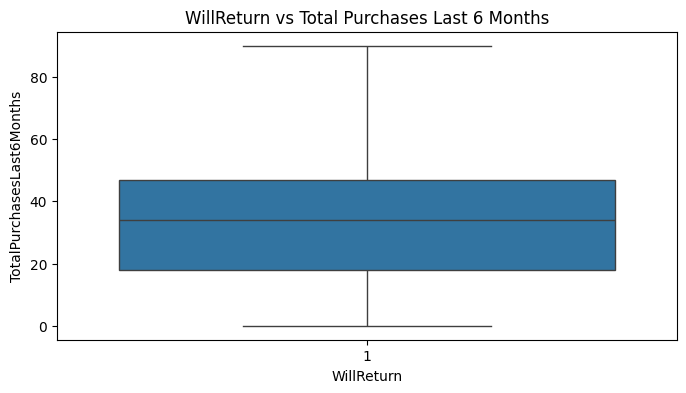

In [165]:
plt.figure(figsize=(8,4))
sns.boxplot(x='WillReturn', y='TotalPurchasesLast6Months', data=df)
plt.title('WillReturn vs Total Purchases Last 6 Months')
plt.show()



Returning customers generally have more purchases in the last 6 months

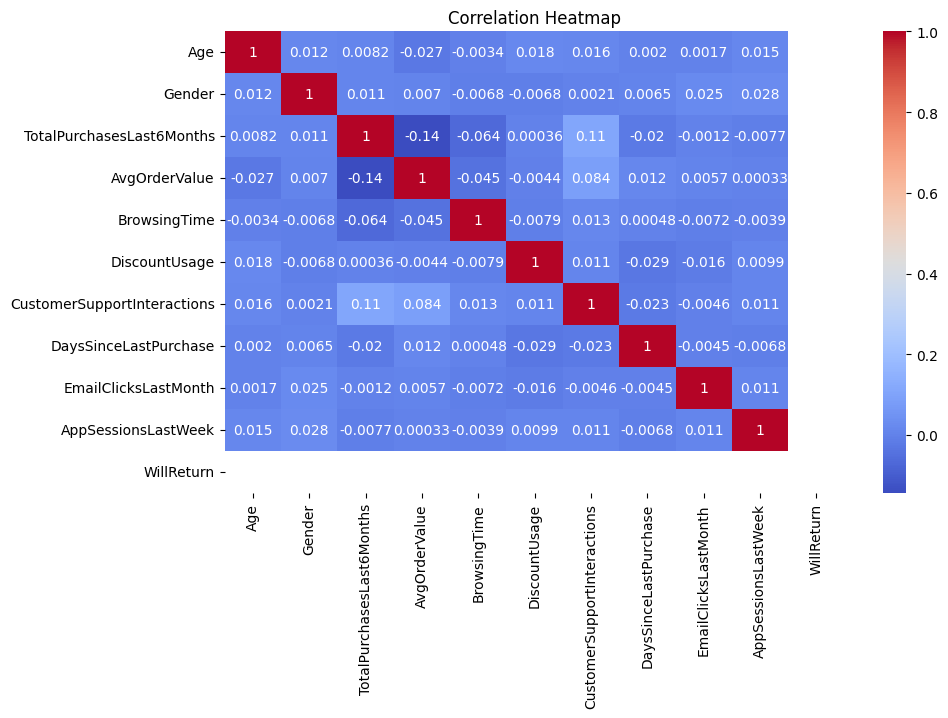

In [188]:
plt.figure(figsize=(10,6))
corr = df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()


Features like TotalPurchasesLast6Months, AvgOrderValue, BrowsingTime, and DaysSinceLastPurchase are positively correlated with WillReturn

##Split the x and y variable

In [167]:
#split the dataset into x and y
# In the x it will include the everything except the target and the in the y only target variable
X=df.drop('WillReturn',axis=1)
y=df['WillReturn']

##Train_Test_Split

In [168]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

##Feature Scaling

In [169]:
from sklearn.preprocessing import StandardScaler

ss = StandardScaler()
X_train = ss.fit_transform(X_train)
X_test = ss.transform(X_test)

##ML Model Building

In [170]:
#Initializing the model
from sklearn.naive_bayes import GaussianNB as nb
from sklearn.ensemble import RandomForestClassifier as rf
from sklearn.tree import DecisionTreeClassifier as dt
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score


In [171]:
nb = nb()
rf = rf()
dt = dt()

In [172]:
## Training the model

nb.fit(X_train, y_train)
rf.fit(X_train, y_train)
dt.fit(X_train, y_train)

DecisionTreeClassifier()

In [173]:
## Model evaluation

nb_pred = nb.predict(X_test)
rf_pred = rf.predict(X_test)
dt_pred = dt.predict(X_test)

In [174]:
## Confusion matrix print for all

print("Confusion matrix for Naive Bayes")
print(confusion_matrix(y_test, nb_pred))

Confusion matrix for Naive Bayes
[[835]]


In [175]:
print("Confusion matrix for Random Forest")
print(confusion_matrix(y_test, rf_pred))

Confusion matrix for Random Forest
[[835]]


In [176]:
print("Confusion matrix for Decision Tree")
print(confusion_matrix(y_test, dt_pred))

Confusion matrix for Decision Tree
[[835]]


In [177]:
nb_acc = accuracy_score(y_test, nb_pred)
rf_acc = accuracy_score(y_test, rf_pred)
dt_acc =accuracy_score(y_test, dt_pred)

In [178]:
print("Accuracy for Naive Bayes: ", nb_acc)
print("Accuracy for Random Forest: ", rf_acc)
print("Accuracy for Decision Tree: ", dt_acc)

Accuracy for Naive Bayes:  1.0
Accuracy for Random Forest:  1.0
Accuracy for Decision Tree:  1.0


In [179]:
best_model = rf

In [180]:


# New customer input data
new_data = pd.DataFrame({
    'Age': [28],
    'Gender': ['Male'],  # use 'Male' or 'Female'
    'TotalPurchasesLast6Months': [5],
    'AvgOrderValue': [250],
    'BrowsingTime': [120],
    'DiscountUsage': [2],
    'CustomerSupportInteractions': [1],
    'DaysSinceLastPurchase': [10],
    'EmailClicksLastMonth': [4],
    'AppSessionsLastWeek': [6]
})

new_data

,Age,Gender,TotalPurchasesLast6Months,AvgOrderValue,BrowsingTime,DiscountUsage,CustomerSupportInteractions,DaysSinceLastPurchase,EmailClicksLastMonth,AppSessionsLastWeek
0,28,Male,5,250,120,2,1,10,4,6


In [183]:
new_data['Gender'] = le.transform(new_data['Gender'])

# Scale the numerical features of the new data using the same StandardScaler
# Note: The original X includes 'Gender' as numerical after encoding. So, we scale all columns.
new_data_scaled = ss.transform(new_data)

prediction = best_model.predict(new_data_scaled)

In [184]:
prediction

array([1])

In [185]:
## Interpret the prediction

if prediction[0] == 1:
    print("The model predicts the customer WILL return.")
else:
    print("The model predicts the customer WILL NOT return.")

The model predicts the customer WILL return.


##Overall Analysis

- The dataset contains customer demographic, behavioral, and engagement features, which help in predicting whether a customer will return to shop
- From the analysis, purchase-related features such as TotalPurchasesLast6Months and AvgOrderValue play a major role in identifying returning customers
-  Customers who purchase frequently and spend more are more likely to return
- Customer engagement features like BrowsingTime, EmailClicksLastMonth, and AppSessionsLastWeek also show a strong influence
-  Higher engagement indicates higher chances of returning
- CustomerSupportInteractions shows an inverse relationship, where customers with many complaints or issues are less likely to return
